# Dataset Exploration — movilidad_news.json

Explores the 421-article production dataset: publication timeline, source breakdown,
existing topic distribution, and NLP service reclassification on the full corpus.

**No service required** for sections 1–3. Section 4 onwards calls `/classify` and `/geotag`.

In [10]:
import json, sys, time, collections
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

sys.path.insert(0, '.')
from _scorecard import NLP_BASE_URL, HEADERS

DATA_PATH = Path('../../frontend/src/data/movilidad_news.json')
articles = json.loads(DATA_PATH.read_text(encoding='utf-8'))
df = pd.DataFrame(articles)
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
print(f"Loaded {len(df)} articles  |  date range: {df['publication_date'].min().date()} → {df['publication_date'].max().date()}")
df.head(3)

ModuleNotFoundError: No module named 'pandas'

## 1. Publication timeline

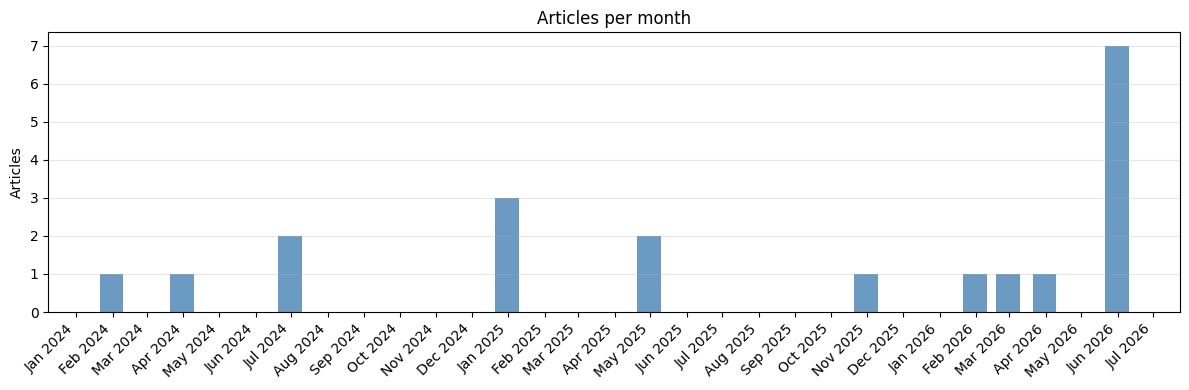

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
monthly = df.set_index('publication_date').resample('ME').size()
ax.bar(monthly.index, monthly.values, width=20, color='steelblue', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Articles')
ax.set_title('Articles per month')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Source breakdown

In [2]:
source_counts = df['source'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — top 15
top15 = source_counts.head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Articles')
axes[0].set_title('Top 15 sources')
axes[0].grid(axis='x', alpha=0.3)

# Pie — top 8 + other
top8 = source_counts.head(8)
other = source_counts[8:].sum()
pie_data = list(top8.values) + [other]
pie_labels = list(top8.index) + ['Other']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Source share')

plt.tight_layout()
plt.show()
print(f"Total unique sources: {df['source'].nunique()}")

NameError: name 'df' is not defined

## 3. Existing topic distribution (from JSON)

In [3]:
all_topics = [t for ts in df['topics'].dropna() for t in (ts if isinstance(ts, list) else [])]
topic_counts = collections.Counter(all_topics)
top_topics = topic_counts.most_common(25)

labels_t, values_t = zip(*top_topics)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(list(labels_t)[::-1], list(values_t)[::-1], color='darkorange', alpha=0.8)
ax.set_xlabel('Occurrences')
ax.set_title('Top 25 topic tags (from JSON metadata)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Total unique topic tags: {len(topic_counts)}")        

NameError: name 'df' is not defined

## 4. Relevance score distribution — full corpus

Calls the NLI model directly to score each article's **description** against the relevance
hypothesis, bypassing the service threshold. Shows whether the corpus is clean or has
many borderline articles.

> Uses `description` (short blurb), not the full article body — the full text is not stored in the JSON.

In [4]:
from transformers import pipeline as hf_pipeline

_RELEVANCE_HYPOTHESIS = (
    "Este artículo trata sobre movilidad urbana alternativa: ciclismo en ciudad, "
    "bicicletas, patinetes, peatonalización, infraestructura para transporte activo "
    "o política de movilidad sostenible urbana."
)
_MODEL = "Recognai/bert-base-spanish-wwm-cased-xnli"

print(f"Loading {_MODEL} ...")
nli = hf_pipeline("zero-shot-classification", model=_MODEL)
print("Done.")

/Users/alvarodelser/Projects/nlp_service/.nlp_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Recognai/bert-base-spanish-wwm-cased-xnli ...


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Done.


In [5]:
# Score all articles — may take a few minutes
relevance_scores = []
for i, row in df.iterrows():
    text = str(row.get('description') or row.get('headline') or '')
    if not text.strip():
        relevance_scores.append(0.0)
        continue
    out = nli(text, candidate_labels=[_RELEVANCE_HYPOTHESIS], multi_label=True)
    relevance_scores.append(out['scores'][0])
    if i % 50 == 0:
        print(f"  {i}/{len(df)} done...")

df['relevance_score'] = relevance_scores
print(f"\nDone. Mean={df['relevance_score'].mean():.3f}  Median={df['relevance_score'].median():.3f}")

NameError: name 'df' is not defined

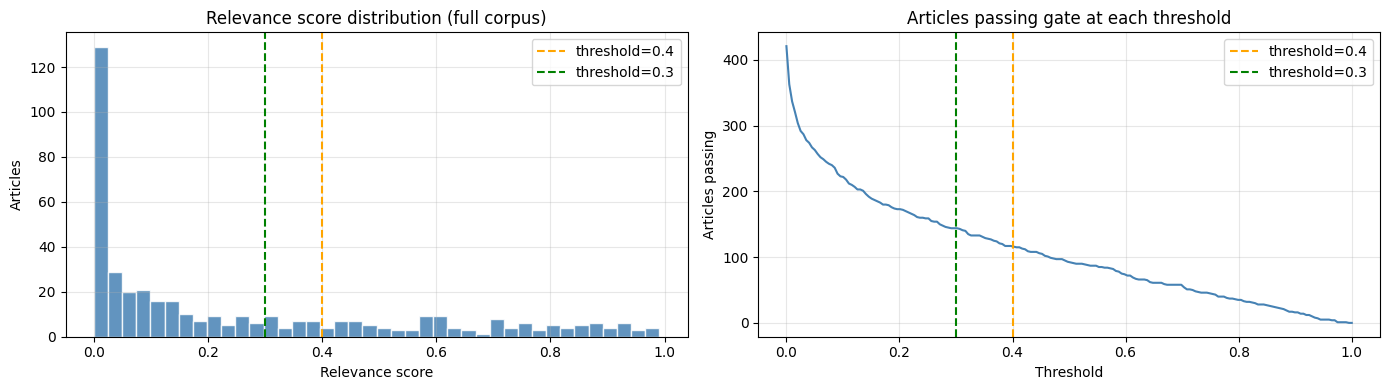

  threshold=0.20  passing=173/421 (41.1%)
  threshold=0.25  passing=159/421 (37.8%)
  threshold=0.30  passing=144/421 (34.2%)
  threshold=0.35  passing=131/421 (31.1%)
  threshold=0.40  passing=116/421 (27.6%)
  threshold=0.45  passing=105/421 (24.9%)
  threshold=0.50  passing=92/421 (21.9%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['relevance_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0.4, color='orange', linestyle='--', label='threshold=0.4')
axes[0].axvline(0.3, color='green',  linestyle='--', label='threshold=0.3')
axes[0].set_xlabel('Relevance score')
axes[0].set_ylabel('Articles')
axes[0].set_title('Relevance score distribution (full corpus)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative — how many articles pass at each threshold
import numpy as np
thresholds = np.linspace(0, 1, 200)
passing = [(df['relevance_score'] >= t).sum() for t in thresholds]
axes[1].plot(thresholds, passing, color='steelblue')
axes[1].axvline(0.4, color='orange', linestyle='--', label='threshold=0.4')
axes[1].axvline(0.3, color='green',  linestyle='--', label='threshold=0.3')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Articles passing')
axes[1].set_title('Articles passing gate at each threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    n = (df['relevance_score'] >= t).sum()
    print(f"  threshold={t:.2f}  passing={n}/{len(df)} ({100*n/len(df):.1f}%)")

## 5. Topic clustering — NLP reclassification

Calls `/classify` on each article description via the service.
Compares service-assigned topics against the JSON metadata tags.

**Prerequisite:** NLP service running and reachable.

In [ ]:
# NOTE: /classify now expects summary + geo_cities (not raw text).
# We use the article description as a proxy summary (no LLM in this pass).
# For a production-quality run, pipe through /extract + /summarize first.
import requests

service_topics = []
service_scope = []
errors = 0

for i, row in df.iterrows():
    proxy_summary = str(row.get('description') or row.get('headline') or '')
    if not proxy_summary.strip():
        service_topics.append([])
        service_scope.append(None)
        continue
    try:
        resp = requests.post(
            f'{NLP_BASE_URL}/classify',
            json={
                'article_id': row['id'],
                'summary': proxy_summary,
                'geo_cities': [],      # no geotag pass here
                'search_tags': [],
                'source_profile': None,
            },
            headers=HEADERS,
            timeout=30
        )
        data = resp.json()
        service_topics.append(data.get('topics', []))
        service_scope.append(data.get('geo_scope'))
    except Exception as e:
        service_topics.append([])
        service_scope.append(None)
        errors += 1
    if i % 50 == 0:
        print(f'  {i}/{len(df)} done...')

df['service_topics'] = service_topics
df['service_scope']  = service_scope
# Treat articles with no topics as out-of-scope for plotting
df['service_oos'] = df['service_topics'].apply(lambda ts: len(ts) == 0)
oos_count = df['service_oos'].sum()
print(f'\nDone. Errors={errors}  no-topic={oos_count}/{len(df)} ({100*oos_count/len(df):.1f}%)')


In [ ]:
# Compare service topics vs JSON metadata topics on in-scope articles
in_scope_df = df[~df['service_oos']].copy()

service_topic_counts = collections.Counter(
    t for ts in in_scope_df['service_topics'] for t in ts
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Service-assigned topics
top_s = service_topic_counts.most_common(20)
if top_s:
    ls, vs = zip(*top_s)
    axes[0].barh(list(ls)[::-1], list(vs)[::-1], color='steelblue', alpha=0.8)
axes[0].set_title('NLP service topic assignments (in-scope articles)')
axes[0].set_xlabel('Assignments')
axes[0].grid(axis='x', alpha=0.3)

# Articles per topic over time (heatmap-style — top 8 topics)
top8_service = [t for t, _ in service_topic_counts.most_common(8)]
in_scope_df = in_scope_df.copy()
in_scope_df['month'] = in_scope_df['publication_date'].dt.to_period('M')

heat = {}
for topic in top8_service:
    heat[topic] = in_scope_df[in_scope_df['service_topics'].apply(lambda ts: topic in ts)].groupby('month').size()

heat_df = pd.DataFrame(heat).fillna(0)
if not heat_df.empty:
    im = axes[1].imshow(heat_df.T.values, aspect='auto', cmap='YlOrRd')
    axes[1].set_yticks(range(len(top8_service)))
    axes[1].set_yticklabels(top8_service, fontsize=8)
    axes[1].set_xticks(range(len(heat_df.index)))
    axes[1].set_xticklabels([str(p) for p in heat_df.index], rotation=45, ha='right', fontsize=7)
    axes[1].set_title('Topic frequency over time (top 8)')
    plt.colorbar(im, ax=axes[1], label='Articles')

# Geo-scope distribution
scope_counts = in_scope_df['service_scope'].value_counts()
axes[2].bar(scope_counts.index, scope_counts.values, color=['steelblue', 'darkorange', 'green'], alpha=0.8)
axes[2].set_title('Geo-scope distribution (in-scope articles)')
axes[2].set_ylabel('Articles')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Geotag coverage — city distribution

In [ ]:
# NOTE: /geotag now returns geo_cities (list), geo_streets (list), geo_points (list).
# We take the first (highest-confidence) city for per-article plotting.
geo_results = []
errors_geo = 0

for i, row in df.iterrows():
    text = str(row.get('description') or '')
    headline = str(row.get('headline') or '')
    if not text.strip():
        geo_results.append({'city': None, 'city_confidence': 0.0,
                             'geo_streets': 0, 'geo_points': 0})
        continue
    try:
        resp = requests.post(
            f'{NLP_BASE_URL}/geotag',
            json={'article_id': row['id'], 'text': text, 'headline': headline},
            headers=HEADERS,
            timeout=10
        )
        data = resp.json()
        cities = data.get('geo_cities', [])
        top = cities[0] if cities else None
        geo_results.append({
            'city': top['city_name'] if top else None,
            'city_confidence': top['confidence'] if top else 0.0,
            'geo_streets': len(data.get('geo_streets', [])),
            'geo_points': len(data.get('geo_points', [])),
        })
    except Exception:
        geo_results.append({'city': None, 'city_confidence': 0.0,
                             'geo_streets': 0, 'geo_points': 0})
        errors_geo += 1
    if i % 50 == 0:
        print(f'  {i}/{len(df)} done...')

geo_df = pd.DataFrame(geo_results)
df['geo_city']       = geo_df['city']
df['geo_confidence'] = geo_df['city_confidence']
df['geo_streets']    = geo_df['geo_streets']
df['geo_points']     = geo_df['geo_points']
resolved = df['geo_city'].notna().sum()
print(f'City resolved: {resolved}/{len(df)} ({100*resolved/len(df):.1f}%)  Errors={errors_geo}')
print(f'Street spans:  {df["geo_streets"].sum()}  |  Fallback geo_points: {df["geo_points"].sum()}')


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

city_counts = df['geo_city'].dropna().value_counts().head(15)
if not city_counts.empty:
    axes[0].barh(city_counts.index[::-1], city_counts.values[::-1], color='teal', alpha=0.8)
axes[0].set_title('Top cities detected by geotagger')
axes[0].set_xlabel('Articles')
axes[0].grid(axis='x', alpha=0.3)

# Confidence distribution
conf_vals = df.loc[df['geo_city'].notna(), 'geo_confidence']
axes[1].hist(conf_vals, bins=20, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('City confidence score')
axes[1].set_ylabel('Articles')
axes[1].set_title('Geotagger confidence distribution (resolved articles)')
axes[1].grid(alpha=0.3)

# geo_points coverage (unresolved spans kept as lat/lon for map plotting)
has_points = (df['geo_points'] > 0).sum()
no_points  = (df['geo_points'] == 0).sum()
axes[2].bar(['Has geo_points', 'No geo_points'], [has_points, no_points],
            color=['darkorange', 'lightgrey'], alpha=0.85)
axes[2].set_title('Articles with unresolved-but-geocoded spans\n(kept as geo_points for map plotting)')
axes[2].set_ylabel('Articles')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Topic Discovery — BERTopic

Discovers organic topic clusters from the corpus using BERTopic, which combines
sentence embeddings (same model as dedup: `paraphrase-multilingual-MiniLM-L12-v2`)
with UMAP dimensionality reduction and HDBSCAN clustering.

This gives you a data-driven answer to whether the 20 labels in `topics.yaml`
are the right ones and at the right granularity.

If not installed: `pip install bertopic`

In [24]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import numpy as np

# Reuse the same model as the dedup pipeline — no extra download
_EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(_EMBED_MODEL)

# Use headline + description as the document; skip blanks
docs = [
    f"{row['headline']}. {row.get('description') or ''}".strip()
    for _, row in df.iterrows()
]
docs = [d if d.strip('.') else '[empty]' for d in docs]

print(f"Encoding {len(docs)} documents with {_EMBED_MODEL} ...")
embeddings = embedder.encode(docs, show_progress_bar=True, normalize_embeddings=True)
print(f"Embedding matrix: {embeddings.shape}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 421 documents with paraphrase-multilingual-MiniLM-L12-v2 ...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embedding matrix: (421, 384)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords as _nltk_sw

_es_stop = list(_nltk_sw.words('spanish'))
_vectorizer = CountVectorizer(stop_words=_es_stop, ngram_range=(1, 2), min_df=2)

topic_model = BERTopic(
    language='multilingual',
    min_topic_size=5,
    nr_topics='auto',
    verbose=True,
    vectorizer_model=_vectorizer,
)
topics, probs = topic_model.fit_transform(docs, embeddings)
df['bertopic_id'] = topics

info = topic_model.get_topic_info()
print(f"\nDiscovered {len(info[info.Topic != -1])} topics  |  outliers (topic -1): {(df['bertopic_id'] == -1).sum()}")
info.head(20)

In [26]:
# Print top keywords per topic for manual labelling
print("Top keywords per discovered topic:\n")
for topic_id in sorted(info[info.Topic != -1].Topic):
    words = topic_model.get_topic(topic_id)
    keywords = ', '.join(w for w, _ in words[:8])
    count = (df['bertopic_id'] == topic_id).sum()
    print(f"  Topic {topic_id:3d}  ({count:3d} articles)  {keywords}")

Top keywords per discovered topic:

  Topic   0  ( 94 articles)  carril, bici, del, de, el, la, nuevo, obras
  Topic   1  ( 31 articles)  infraestructura, ciclista, ciclistas, la, en, para, ley, prioridad
  Topic   2  ( 27 articles)  urbana, movilidad, sostenible, la, de, una, para, patinetes
  Topic   3  ( 26 articles)  españa, bicicleta, en, el, la, de, rutas, las
  Topic   4  ( 18 articles)  pamplona, cuesta, calle, reina, la, de, urbano, al
  Topic   5  ( 15 articles)  eléctricas, bicicletas, eléctrica, motor, híbridos, obligatorio, las, eléctricos
  Topic   6  ( 15 articles)  millones, 177, en, bicicleta, 000, españa, empleos, 2025
  Topic   7  ( 14 articles)  valència, valencia, ciudad, en, guadalajara, mejor, bici, ciclista
  Topic   8  ( 13 articles)  madrid, movilidad, europea, urbana, telpark, aérea, plataforma, digital
  Topic   9  ( 13 articles)  urbana, movilidad, yurni, toledo, la, transporte, de, nueva
  Topic  10  ( 11 articles)  plan, sostenible, urbana, movilidad, ciu

In [27]:
# Compare BERTopic clusters vs taxonomy labels
# For each taxonomy label, show which BERTopic topic the articles that have it cluster into
taxonomy_labels = [
    'infraestructura ciclista', 'carril bici', 'accidente de tráfico',
    'presupuesto municipal', 'movilidad sostenible', 'regulación de movilidad',
    'peatonalización', 'bicicleta eléctrica', 'patinete eléctrico',
    'seguridad vial', 'transporte activo',
]

print("Taxonomy label → dominant BERTopic cluster\n")
for label in taxonomy_labels:
    mask = df['topics'].apply(lambda ts: label in ts if isinstance(ts, list) else False)
    if mask.sum() == 0:
        print(f"  {label:<35}  no articles in corpus")
        continue
    dominant = df.loc[mask, 'bertopic_id'].value_counts().head(3)
    tops = ', '.join(f"topic {t} ({c}x)" for t, c in dominant.items())
    print(f"  {label:<35}  → {tops}")

Taxonomy label → dominant BERTopic cluster

  infraestructura ciclista             → topic 12 (3x), topic 4 (2x), topic -1 (2x)
  carril bici                          no articles in corpus
  accidente de tráfico                 no articles in corpus
  presupuesto municipal                no articles in corpus
  movilidad sostenible                 → topic -1 (3x), topic 1 (3x), topic 12 (2x)
  regulación de movilidad              no articles in corpus
  peatonalización                      no articles in corpus
  bicicleta eléctrica                  no articles in corpus
  patinete eléctrico                   no articles in corpus
  seguridad vial                       → topic 15 (1x), topic 1 (1x)
  transporte activo                    no articles in corpus


In [6]:
# UMAP 2D visualisation — coloured by BERTopic cluster
import umap

reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
coords = reducer.fit_transform(embeddings)
df['umap_x'] = coords[:, 0]
df['umap_y'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
unique_topics = sorted(df['bertopic_id'].unique())
cmap = plt.cm.get_cmap('tab20', max(len(unique_topics), 1))

for i, tid in enumerate(unique_topics):
    mask = df['bertopic_id'] == tid
    label = f'Topic {tid}' if tid != -1 else 'Outlier'
    color = 'lightgrey' if tid == -1 else cmap(i)
    ax.scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
               c=[color], label=label, s=20, alpha=0.7)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, markerscale=2)
ax.set_title('UMAP projection of article embeddings — coloured by BERTopic cluster')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'umap'

In [7]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

# PCA on MiniLM embeddings (384-dim → 2D)
pca7 = PCA(n_components=2, random_state=42)
pca7_coords = pca7.fit_transform(embeddings)
df['pca7_x'] = pca7_coords[:, 0]
df['pca7_y'] = pca7_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: BERTopic clusters ---
unique_topics = sorted(df['bertopic_id'].unique())
cmap_bt = plt.cm.get_cmap('tab20', max(len(unique_topics), 1))
for i, tid in enumerate(unique_topics):
    mask = df['bertopic_id'] == tid
    label = f'Topic {tid}' if tid != -1 else 'Outlier'
    color = 'lightgrey' if tid == -1 else cmap_bt(i)
    axes[0].scatter(df.loc[mask, 'pca7_x'], df.loc[mask, 'pca7_y'],
                    c=[color], label=label, s=18, alpha=0.75)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, markerscale=1.8)
axes[0].set_title(f'PCA — BERTopic clusters (MiniLM 384-dim)\n'
                  f'PC1 {pca7.explained_variance_ratio_[0]:.1%}  PC2 {pca7.explained_variance_ratio_[1]:.1%}')
axes[0].set_xlabel(f'PC1'); axes[0].set_ylabel(f'PC2')

# --- Right: OOS detection ---
# Use service_oos if the classify section ran, else fall back to relevance_score
if 'service_oos' in df.columns:
    colors_oos = df['service_oos'].map({True: 'salmon', False: 'steelblue'})
    axes[1].scatter(df['pca7_x'], df['pca7_y'], c=colors_oos, s=18, alpha=0.75)
    axes[1].legend(handles=[Patch(color='steelblue', label='In-scope'),
                             Patch(color='salmon',    label='OOS')], fontsize=9)
    axes[1].set_title('PCA — OOS detection (service classifier)')
elif 'relevance_score' in df.columns:
    sc = axes[1].scatter(df['pca7_x'], df['pca7_y'], c=df['relevance_score'],
                         cmap='RdYlGn', s=18, alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(sc, ax=axes[1], label='Relevance score')
    axes[1].set_title('PCA — OOS detection (NLI relevance score)')
else:
    axes[1].text(0.5, 0.5, 'Run section 4 or 5 first', transform=axes[1].transAxes, ha='center')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()
print(f'Explained variance: PC1={pca7.explained_variance_ratio_[0]:.3f}  '
      f'PC2={pca7.explained_variance_ratio_[1]:.3f}  '
      f'Total={sum(pca7.explained_variance_ratio_):.3f}')

ModuleNotFoundError: No module named 'matplotlib'

In [8]:
# OOD centroid analysis — how far is each article from the in-scope centroid?
# The centroid is the mean of all non-outlier article embeddings (proxy for in-scope cluster).
# Articles far from the centroid are OOD candidates.

in_scope_mask = df['bertopic_id'] != -1
centroid = embeddings[in_scope_mask].mean(axis=0)
centroid /= np.linalg.norm(centroid)  # normalise

cosine_sims = embeddings @ centroid   # fast — embeddings are already L2-normalised
df['centroid_similarity'] = cosine_sims

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['centroid_similarity'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Cosine similarity to in-scope centroid')
ax.set_ylabel('Articles')
ax.set_title('OOD signal: distance from in-scope centroid')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Lowest-similarity articles (most OOD):")
df.nsmallest(10, 'centroid_similarity')[['headline', 'source', 'centroid_similarity']].to_string(index=False)

NameError: name 'df' is not defined

## 8. Taxonomy Construction — Hybrid Approach

**Strategy**: top-down for the upper two levels (human-legible, stable); bottom-up
(BERTopic) for the leaf level (let the data reveal what exists).

Two separate BERTopic passes to disentangle orthogonal dimensions:
- **Themes** — *what is happening* (Infrastructure, Policy, Incident, Operations…)
- **Modes** — *which transport mode* (Cycling, Scooter/VMP, Walking, Shared…)

A single article can have one theme and one or more modes — they are independent axes.
BERTopic discovers the leaf clusters; an LLM assigns each to a (theme, mode) pair.

**Proposed top-down skeleton** (to be validated/revised from BERTopic output):

| Theme | Description |
|-------|-------------|
| Infraestructura | New lanes, facilities, construction, urban design |
| Política y regulación | ZBE, VMP rules, plans, permits, enforcement |
| Incidentes y seguridad | Accidents, dangerous junctions, safety campaigns |
| Operaciones y servicio | Bikeshare/scootershare operations, disruptions, coverage |
| Comportamiento y datos | Modal share stats, surveys, usage counts, culture |
| Tecnología e innovación | E-bikes, apps, smart infrastructure, sensors |
| Economía e inversión | Budgets, subsidies, funding, industry news |

Modes TBD from BERTopic — see cell below.

### 8.1 Upgrade embedding model for topic modeling

`paraphrase-multilingual-mpnet-base-v2` (768-dim) captures more semantic nuance than
MiniLM (384-dim) and is trained on a larger multilingual corpus — better for
separating thematic clusters in BERTopic.

The MiniLM model stays as-is for dedup and OOD (speed matters there).
Here we only care about cluster quality.

In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

_TOPIC_MODEL = 'paraphrase-multilingual-mpnet-base-v2'  # 768-dim, better topic separation
# Alternative: 'BAAI/bge-m3' — higher quality but 1.7 GB and slower

print(f'Loading {_TOPIC_MODEL} ...')
topic_embedder = SentenceTransformer(_TOPIC_MODEL)

docs = [
    f"{row['headline']}. {row.get('description') or ''}".strip()
    for _, row in df.iterrows()
]
docs = [d if d.strip('.') else '[empty]' for d in docs]

print(f'Encoding {len(docs)} documents ...')
topic_embs = topic_embedder.encode(docs, show_progress_bar=True, normalize_embeddings=True)
print(f'Embedding matrix: {topic_embs.shape}')

Loading paraphrase-multilingual-mpnet-base-v2 ...


NameError: name 'df' is not defined

### 8.2 Bottom-up: leaf cluster discovery (many fine-grained clusters)

Run with small `min_topic_size` to surface granular clusters — these are the *leaf
subtopics*. Many will be junk or near-duplicates; the LLM step will merge/label them.

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords as _nltk_sw

_es_stop = list(_nltk_sw.words('spanish'))
_vec8 = CountVectorizer(stop_words=_es_stop, ngram_range=(1, 2), min_df=2)

umap_model = UMAP(n_components=5, n_neighbors=10, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=4, min_samples=2, metric='euclidean',
                         cluster_selection_method='eom', prediction_data=True)

leaf_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='multilingual',
    nr_topics='auto',
    verbose=False,
    vectorizer_model=_vec8,
)
leaf_topics, _ = leaf_model.fit_transform(docs, topic_embs)
df['leaf_topic'] = leaf_topics

leaf_info = leaf_model.get_topic_info()
n_real = len(leaf_info[leaf_info.Topic != -1])
n_outlier = (df['leaf_topic'] == -1).sum()
print(f'Leaf clusters: {n_real}  |  outliers: {n_outlier}/{len(df)}')
leaf_info[leaf_info.Topic != -1].head(30)

In [32]:
print('Leaf cluster keyword summary:\n')
for tid in sorted(leaf_info[leaf_info.Topic != -1].Topic):
    words = leaf_model.get_topic(tid)
    kw = ', '.join(w for w, _ in words[:10])
    n = (df['leaf_topic'] == tid).sum()
    print(f'  Cluster {tid:3d}  ({n:3d} docs)  {kw}')

Leaf cluster keyword summary:

  Cluster   0  (206 docs)  de, la, bici, el, en, carril, del, ciclista, bicicleta, las
  Cluster   1  ( 35 docs)  movilidad, urbana, sostenible, la, con, madrid, de, en, ayuntamiento, el
  Cluster   2  ( 12 docs)  millones, 177, 000, bicicleta, en, empleos, españa, 2025, 121, industria
  Cluster   3  ( 12 docs)  plan, sostenible, urbana, movilidad, ciudadana, ayuntamiento, del, el, participativo, comus
  Cluster   4  ( 11 docs)  patinetes, seguridad, urbana, movilidad, eléctricos, vial, la, vmp, mgs, stormshield
  Cluster   5  ( 10 docs)  urbana, movilidad, tecnología, datos, comillas, databricks, femp, qué, es, la
  Cluster   6  (  9 docs)  motor, eléctricas, eléctrica, bicicletas, híbridos, no, bicicleta, eléctricos, español, mejores
  Cluster   7  (  6 docs)  boe, oficial, los, adiós, hace, carreteras, ciclistas, cambio, lo, arcenes
  Cluster   8  (  6 docs)  yurni, toledo, telpark, aplicación, nueva, movilidad, impacta, prelanzamiento, rte, responsabl

### 8.3 Bottom-up: theme-level clustering (coarse — 6 to 12 clusters)

Force fewer clusters to reveal the top-level thematic signal.
Compare against the proposed top-down theme skeleton above.

In [ ]:
umap_coarse = UMAP(n_components=5, n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
hdbscan_coarse = HDBSCAN(min_cluster_size=20, metric='euclidean',
                          cluster_selection_method='eom', prediction_data=True)

theme_model = BERTopic(
    umap_model=umap_coarse,
    hdbscan_model=hdbscan_coarse,
    language='multilingual',
    nr_topics=10,
    verbose=False,
    vectorizer_model=_vec8,
)
theme_topics, _ = theme_model.fit_transform(docs, topic_embs)
df['theme_topic'] = theme_topics

theme_info = theme_model.get_topic_info()
print(f'Theme clusters: {len(theme_info[theme_info.Topic != -1])}  |  '
      f'outliers: {(df["theme_topic"] == -1).sum()}')

print('\nTheme cluster keywords:\n')
for tid in sorted(theme_info[theme_info.Topic != -1].Topic):
    words = theme_model.get_topic(tid)
    kw = ', '.join(w for w, _ in words[:10])
    n = (df['theme_topic'] == tid).sum()
    print(f'  Theme {tid:3d}  ({n:3d} docs)  {kw}')

### 8.4 Bottom-up: mode-level clustering (unseeded)

Same approach as leaf clustering but tuned for coarser mode-level granularity.
**No seed words** — the whole point is to let the data reveal which transport modes
actually dominate the corpus, including combinations and hybrids you wouldn't predict.
Seeds would inject top-down assumptions and defeat the bottom-up pass.

In [ ]:
umap_mode = UMAP(n_components=5, n_neighbors=15, min_dist=0.05, metric='cosine', random_state=42)
hdbscan_mode = HDBSCAN(min_cluster_size=8, metric='euclidean',
                        cluster_selection_method='eom', prediction_data=True)

mode_model = BERTopic(
    umap_model=umap_mode,
    hdbscan_model=hdbscan_mode,
    language='multilingual',
    nr_topics='auto',
    verbose=False,
    vectorizer_model=_vec8,
)
mode_topics, _ = mode_model.fit_transform(docs, topic_embs)
df['mode_topic'] = mode_topics

mode_info = mode_model.get_topic_info()
print(f'Mode clusters: {len(mode_info[mode_info.Topic != -1])}  |  '
      f'outliers: {(df["mode_topic"] == -1).sum()}')

print('\nMode cluster keywords (emergent — no seeds):\n')
for tid in sorted(mode_info[mode_info.Topic != -1].Topic):
    words = mode_model.get_topic(tid)
    kw = ', '.join(w for w, _ in words[:10])
    n = (df['mode_topic'] == tid).sum()
    print(f'  Mode {tid:3d}  ({n:3d} docs)  {kw}')

In [ ]:
# PCA on mpnet embeddings (768-dim → 2D) — coloured by leaf / theme / mode
from sklearn.decomposition import PCA

pca8 = PCA(n_components=2, random_state=42)
pca8_coords = pca8.fit_transform(topic_embs)
df['pca8_x'] = pca8_coords[:, 0]
df['pca8_y'] = pca8_coords[:, 1]

_configs = [
    ('leaf_topic',  leaf_info,  'Leaf clusters',  'tab20'),
    ('theme_topic', theme_info, 'Theme clusters', 'Set2'),
    ('mode_topic',  mode_info,  'Mode clusters',  'Set1'),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (col, info_df, title, cmap_name) in zip(axes, _configs):
    unique_ids = sorted(df[col].unique())
    cmap = plt.cm.get_cmap(cmap_name, max(len(unique_ids), 1))
    for i, tid in enumerate(unique_ids):
        mask = df[col] == tid
        color = 'lightgrey' if tid == -1 else cmap(i)
        label = f'{tid}' if tid != -1 else 'Outlier'
        ax.scatter(df.loc[mask, 'pca8_x'], df.loc[mask, 'pca8_y'],
                   c=[color], label=label, s=18, alpha=0.75)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, markerscale=1.8)
    ax.set_title(f'PCA — {title} (mpnet 768-dim)\n'
                 f'PC1 {pca8.explained_variance_ratio_[0]:.1%}  PC2 {pca8.explained_variance_ratio_[1]:.1%}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()
print(f'Explained variance: PC1={pca8.explained_variance_ratio_[0]:.3f}  '
      f'PC2={pca8.explained_variance_ratio_[1]:.3f}  '
      f'Total={sum(pca8.explained_variance_ratio_):.3f}')

### 8.5 LLM cluster labeling (Ollama)

For each leaf cluster, call Ollama with the top keywords and 5 representative headlines.
The model assigns a label, theme, and mode — and flags two discard conditions:

- **`is_location`** — cluster is dominated by a place name (city, region, street) without
  a distinct topical signal. Locations are handled by the geotagger, not the taxonomy.
- **`is_top_level_duplicate`** — cluster merely restates an existing top-level theme or mode
  category without adding leaf-level specificity (e.g. a cluster whose signal is just
  'bicicleta' — that's a mode, not a leaf subtopic).

Both flags → `discard=True`. Only non-discarded clusters with sufficient coverage enter
the taxonomy candidate list.

In [ ]:
import os, requests, json as _json

# Ollama is accessed through the NLP service proxy (/ollama/...) so the notebook
# works locally without a direct connection to the Docker network.
OLLAMA_PROXY = os.environ.get('OLLAMA_PROXY', f'{NLP_BASE_URL}/ollama')
OLLAMA_MODEL = os.environ.get('OLLAMA_MODEL', 'gemma3:4b')

_LABEL_SCHEMA = {
    'type': 'object',
    'properties': {
        'cluster_label': {'type': 'string'},
        'theme': {
            'type': 'string',
            'enum': ['Infraestructura', 'Política y regulación',
                     'Incidentes y seguridad', 'Operaciones y servicio',
                     'Comportamiento y datos', 'Tecnología e innovación',
                     'Economía e inversión', 'Otro'],
        },
        'mode': {
            'type': 'string',
            'enum': ['Bicicleta', 'Bicicleta eléctrica', 'Patinete y VMP',
                     'Peatonal', 'Movilidad compartida', 'Tráfico y ZBE',
                     'Intermodal', 'Logística urbana', 'Multimodo', 'No aplica'],
        },
        'is_location': {
            'type': 'boolean',
            'description': 'True if the cluster signal is primarily a place name '
                           '(city, region, street, neighbourhood) without a distinct '
                           'topical meaning beyond geography.',
        },
        'is_top_level_duplicate': {
            'type': 'boolean',
            'description': 'True if the cluster merely restates an existing top-level '
                           'theme or mode category without adding leaf-level specificity.',
        },
        'sibling_subtopics': {
            'type': 'array',
            'items': {'type': 'string'},
            'description': '3 sibling leaf subtopics that would sit next to this one.',
        },
        'notes': {'type': 'string'},
    },
    'required': ['cluster_label', 'theme', 'mode',
                 'is_location', 'is_top_level_duplicate', 'sibling_subtopics'],
}

_TOP_DOWN_CONTEXT = (
    'Top-level themes already defined (do NOT replicate at leaf level): '
    'Infraestructura, Política y regulación, Incidentes y seguridad, '
    'Operaciones y servicio, Comportamiento y datos, Tecnología e innovación, '
    'Economía e inversión.\n'
    'Top-level modes already defined (do NOT replicate at leaf level): '
    'Bicicleta, Bicicleta eléctrica, Patinete y VMP, Peatonal, '
    'Movilidad compartida, Tráfico y ZBE, Intermodal, Logística urbana.\n'
    'Spanish cities and regions (location signals to flag): '
    'Madrid, Barcelona, Sevilla, Valencia, Bilbao, Zaragoza, Málaga, '
    'Comunidad de Madrid, Cataluña, Andalucía, País Vasco, and similar.'
)


def label_cluster(cluster_id: int, keywords: list[str], sample_headlines: list[str]) -> dict:
    prompt = (
        'You are a taxonomy expert in urban mobility and transport policy in Spain.\n'
        f'{_TOP_DOWN_CONTEXT}\n\n'
        'Below is a BERTopic leaf cluster from a corpus of Spanish mobility news.\n'
        f'Top keywords: {", ".join(keywords[:12])}\n'
        'Sample headlines:\n' +
        '\n'.join(f'  - {h}' for h in sample_headlines[:5]) +
        '\n\nAssign this cluster a specific leaf-level label (NOT a top-level category). '
        'Set is_location=true if the cluster signal is primarily geographic. '
        'Set is_top_level_duplicate=true if it only repeats a top-level theme/mode. '
        'Suggest 3 sibling subtopics at the same leaf level.'
    )
    resp = requests.post(
        f'{OLLAMA_PROXY}/generate',
        json={'model': OLLAMA_MODEL, 'prompt': prompt,
              'stream': False, 'format': _LABEL_SCHEMA},
        headers=HEADERS,
        timeout=120,
    )
    resp.raise_for_status()
    return _json.loads(resp.json()['response'])


try:
    r = requests.get(f'{OLLAMA_PROXY}/tags', headers=HEADERS, timeout=10)
    r.raise_for_status()
    models = [m['name'] for m in r.json().get('models', [])]
    print(f'Ollama proxy reachable. Available models: {models}')
    if OLLAMA_MODEL not in models:
        print(f'WARNING: {OLLAMA_MODEL} not listed — run: docker exec ollama ollama pull {OLLAMA_MODEL}')
except Exception as e:
    print(f'WARNING: Ollama proxy not reachable ({e}). Deploy NLP service first.')

In [38]:
proposals = []
failed = []

cluster_ids = sorted(leaf_info[leaf_info.Topic != -1].Topic.tolist())
print(f'Labelling {len(cluster_ids)} clusters...\n')

for tid in cluster_ids:
    words = leaf_model.get_topic(tid)
    keywords = [w for w, _ in words[:12]]
    mask = df['leaf_topic'] == tid
    samples = df.loc[mask, 'headline'].dropna().tolist()[:5]

    try:
        result = label_cluster(tid, keywords, samples)
        result['cluster_id'] = tid
        result['doc_count'] = int(mask.sum())
        result['keywords'] = keywords
        result['discard'] = result.get('is_location', False) or result.get('is_top_level_duplicate', False)
        proposals.append(result)

        flags = []
        if result.get('is_location'):            flags.append('LOCATION')
        if result.get('is_top_level_duplicate'): flags.append('TOP-LEVEL-DUP')
        flag_str = '  [' + ' | '.join(flags) + ']' if flags else ''
        print(f'  [{tid:3d}] {result["cluster_label"]:<40}  '
              f'theme={result["theme"]:<25}  mode={result["mode"]}{flag_str}')
    except Exception as e:
        print(f'  [{tid:3d}] FAILED: {e}')
        failed.append(tid)

discarded = sum(1 for p in proposals if p['discard'])
print(f'\nDone. {len(proposals)} labelled, {discarded} discarded '
      f'({discarded - sum(1 for p in proposals if p.get("is_location") and not p.get("is_top_level_duplicate"))} location, '
      f'{sum(1 for p in proposals if p.get("is_top_level_duplicate"))} top-level dup), '
      f'{len(failed)} failed.')

Labelling 16 clusters...

  [  0] FAILED: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x30cd01d50>: Failed to establish a new connection: [Errno 61] Connection refused'))
  [  1] FAILED: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x30cc8b790>: Failed to establish a new connection: [Errno 61] Connection refused'))
  [  2] FAILED: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x30cccf1d0>: Failed to establish a new connection: [Errno 61] Connection refused'))
  [  3] FAILED: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connect

In [39]:
import pandas as pd

prop_df = pd.DataFrame(proposals)

_json.dump(proposals, open('taxonomy_proposals.json', 'w', encoding='utf-8'),
           ensure_ascii=False, indent=2)
print('Saved to taxonomy_proposals.json\n')

# Show discard breakdown
total = len(prop_df)
loc_count = prop_df['is_location'].sum()
dup_count = prop_df['is_top_level_duplicate'].sum()
keep_count = (~prop_df['discard']).sum()
print(f'Clusters: {total} total  |  {loc_count} location  |  '
      f'{dup_count} top-level dup  |  {keep_count} retained for taxonomy\n')

# Theme × mode heatmap — retained clusters only
kept = prop_df[~prop_df['discard']]
if len(kept) > 0:
    pivot = kept.groupby(['theme', 'mode'])['doc_count'].sum().unstack(fill_value=0)
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                        color='white' if v > pivot.values.max() * 0.6 else 'black')
    plt.colorbar(im, ax=ax, label='Articles')
    ax.set_title('Theme × Mode coverage (retained leaf clusters only)')
    plt.tight_layout()
    plt.show()
else:
    print('No retained clusters to plot.')

Saved to taxonomy_proposals.json



KeyError: 'is_location'

In [40]:
# Proposed flat label list for topics.yaml (non-noise clusters above a size threshold)
MIN_DOCS = 5
candidates = non_noise[non_noise['doc_count'] >= MIN_DOCS].sort_values(
    ['theme', 'mode', 'doc_count'], ascending=[True, True, False]
)

print('=== Proposed taxonomy labels (for topics.yaml) ===\n')
print(f'{"Label":<45} {"Theme":<28} {"Mode":<22} {"Docs"}')
print('-' * 105)
for _, row in candidates.iterrows():
    print(f'{row["cluster_label"]:<45} {row["theme"]:<28} {row["mode"]:<22} {row["doc_count"]}')

print(f'\n→ {len(candidates)} candidate labels  '
      f'(covering {candidates["doc_count"].sum()} / {len(df)} articles)')

# YAML-ready output
yaml_labels = candidates['cluster_label'].tolist()
print('\n=== topics.yaml labels block ===')
print('labels:')
for lbl in yaml_labels:
    print(f'  - {lbl}')

NameError: name 'non_noise' is not defined

In [41]:
# Manual review helper — print full detail for any cluster you want to inspect
def inspect_cluster(cluster_id: int, n_samples: int = 8) -> None:
    row = prop_df[prop_df['cluster_id'] == cluster_id].iloc[0]
    mask = df['leaf_topic'] == cluster_id
    print(f'Cluster {cluster_id}: {row["cluster_label"]}')
    print(f'  Theme: {row["theme"]}  |  Mode: {row["mode"]}  |  '
          f'Docs: {row["doc_count"]}  |  Noise: {row["is_noise"]}')
    print(f'  Keywords: {", ".join(row["keywords"][:10])}')
    print(f'  Siblings suggested: {", ".join(row.get("sibling_subtopics", []))}')
    if row.get('notes'):
        print(f'  Notes: {row["notes"]}')
    print(f'  Sample headlines:')
    for h in df.loc[mask, 'headline'].dropna().tolist()[:n_samples]:
        print(f'    • {h}')

# Example: inspect_cluster(0)
print('Call inspect_cluster(N) to review any cluster in detail.')
print('Edit taxonomy_proposals.json manually to merge/rename before updating topics.yaml.')

Call inspect_cluster(N) to review any cluster in detail.
Edit taxonomy_proposals.json manually to merge/rename before updating topics.yaml.
